# Project Title: Multi-Channel Sales Attribution (E-commerce Funnel)

**Goal:** Build a Classification model to predict whether a customer will convert (make a purchase) based on their interactions with various marketing channels and website behavior.

*Note: Since a specific dataset link was not provided, this notebook generates a realistic synthetic e-commerce funnel dataset to demonstrate the complete machine learning workflow.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1. Data Loading / Generation

In [8]:

df = pd.read_csv('ecommerce_funnel_data.csv')

# Clean up negative times
df['Time_on_Site_mins'] = df['Time_on_Site_mins'].clip(lower=0.5)

# Create a target variable 'Converted' (1 = Yes, 0 = No)
# Higher engagement across channels increases probability of conversion
engagement_score = (
    df['Social_Media_Clicks'] * 0.2 +
    df['Email_Opens'] * 0.3 +
    df['Paid_Search_Clicks'] * 0.5 +
    df['Organic_Search_Visits'] * 0.4 +
    df['Time_on_Site_mins'] * 0.1 +
    df['Pages_Visited'] * 0.2
)

# Convert to probabilities and then binary classes
probabilities = 1 / (1 + np.exp(-(engagement_score - 2.5))) # Sigmoid function
df['Converted'] = np.random.binomial(1, probabilities)

print('Shape:', df.shape)
df.head()

Shape: (10000, 7)


,Social_Media_Clicks,Email_Opens,Paid_Search_Clicks,Organic_Search_Visits,Time_on_Site_mins,Pages_Visited,Converted
0,1,2,0,1,3.124376,2,0
1,2,1,0,1,1.913692,1,1
2,2,0,0,1,5.529000,2,0
3,1,2,0,1,1.418043,1,0
4,3,2,0,0,1.973981,4,1


## 2. Exploratory Data Analysis

In [9]:
print("Information about the dataset:\n")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Information about the dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Social_Media_Clicks    10000 non-null  int64  
 1   Email_Opens            10000 non-null  int64  
 2   Paid_Search_Clicks     10000 non-null  int64  
 3   Organic_Search_Visits  10000 non-null  int64  
 4   Time_on_Site_mins      10000 non-null  float64
 5   Pages_Visited          10000 non-null  int64  
 6   Converted              10000 non-null  int64  
dtypes: float64(1), int64(6)
memory usage: 547.0 KB

Statistical Summary:


,Social_Media_Clicks,Email_Opens,Paid_Search_Clicks,Organic_Search_Visits,Time_on_Site_mins,Pages_Visited,Converted
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000
mean,2.158700,1.920300,1.22960,1.914000,5.754259,3.82570,0.541400
std,2.325394,1.944563,1.57605,1.974688,4.602962,3.39907,0.498308
min,0.000000,0.000000,0.00000,0.000000,0.500000,0.00000,0.000000
25%,0.000000,0.000000,0.00000,0.000000,2.458574,1.00000,0.000000
50%,1.000000,1.000000,1.00000,1.000000,3.861334,3.00000,1.000000
75%,3.000000,3.000000,2.00000,3.000000,9.302166,6.00000,1.000000
max,14.000000,16.000000,11.00000,13.000000,21.856615,21.00000,1.000000


## 3. Data Visualization

/tmp/ipykernel_11626/1674505737.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Converted', data=df, palette='viridis')


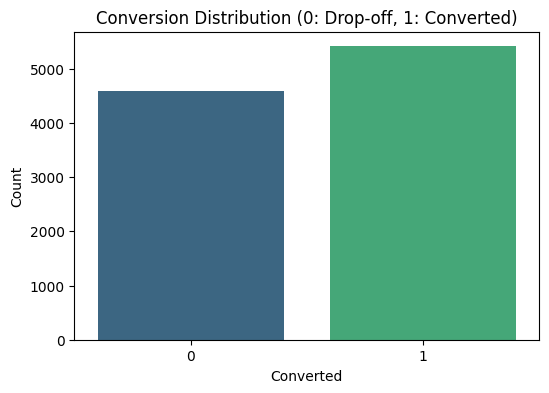

Number of Conversions: 5414
Number of Drop-offs:   4586


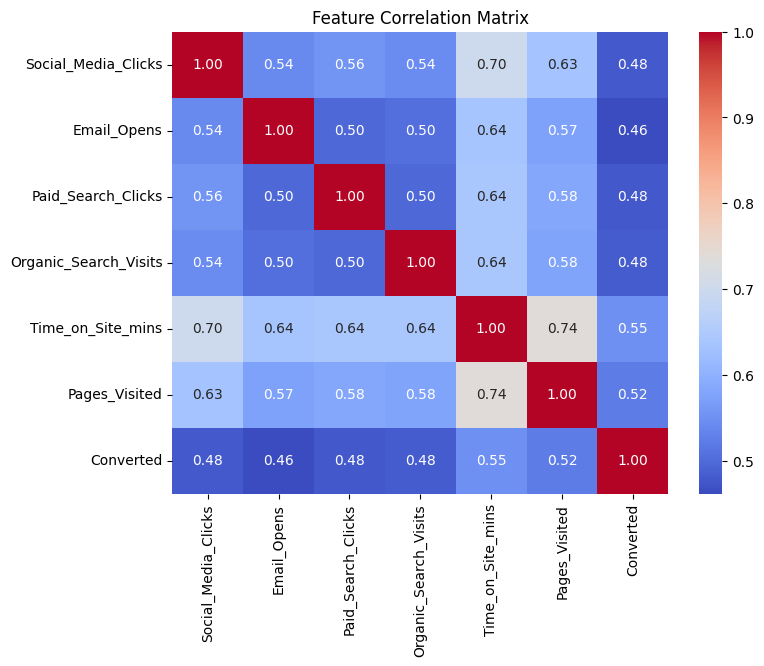

In [10]:
# Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Converted', data=df, palette='viridis')
plt.title('Conversion Distribution (0: Drop-off, 1: Converted)')
plt.xlabel('Converted')
plt.ylabel('Count')
plt.show()

print("Number of Conversions:", (df['Converted']==1).sum())
print("Number of Drop-offs:  ", (df['Converted']==0).sum())

# Feature correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

## 4. Feature Scaling & Data Splitting

In [11]:
X = df.drop(columns=['Converted'])
y = df['Converted']

# Split the data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train size: {X_train.shape}')
print(f'Test size : {X_test.shape}')

Train size: (8000, 6)
Test size : (2000, 6)


## 5. Model Training (Random Forest Classifier)
We use a Random Forest here because it handles non-linear relationships well, which is common in marketing attribution models (e.g., the combined effect of clicking an email AND a paid ad).

In [12]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train_scaled, Y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

## 6. Model Evaluation

Accuracy Score: 73.75%

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.73      0.72       917
           1       0.77      0.74      0.75      1083

    accuracy                           0.74      2000
   macro avg       0.74      0.74      0.74      2000
weighted avg       0.74      0.74      0.74      2000



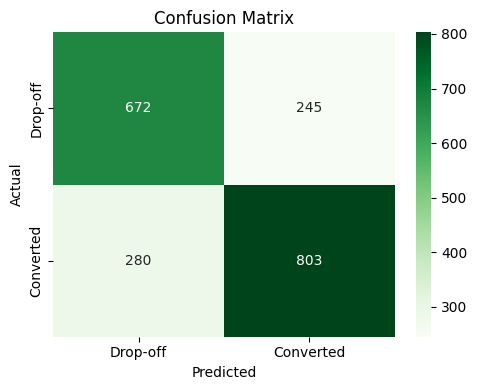

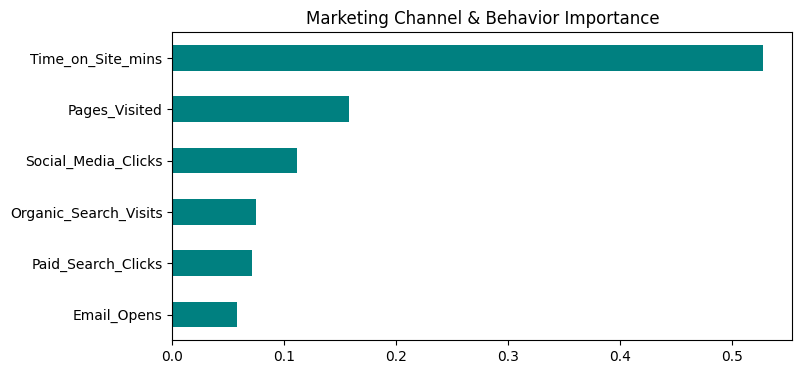

In [13]:
Y_pred = model.predict(X_test_scaled)
acc = accuracy_score(Y_test, Y_pred)

print(f'Accuracy Score: {acc*100:.2f}%\n')
print("Classification Report:")
print(classification_report(Y_test, Y_pred))

# Confusion Matrix Heatmap
matrix = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Drop-off', 'Converted'],
            yticklabels=['Drop-off', 'Converted'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh', color='teal', figsize=(8, 4))
plt.title('Marketing Channel & Behavior Importance')
plt.show()